--- METADATA ---
Tần số lấy mẫu (Fs): 48000 Hz
Số kênh gốc: 2
Độ rộng mẫu: 16 bit/mẫu
Thời lượng tệp gốc: 60.84 giây

--- PHÂN TÍCH MIỀN THỜI GIAN ---
Thời lượng mảng x: 60.84 giây
Peak = 1.0
RMS  = 0.27749768728446955


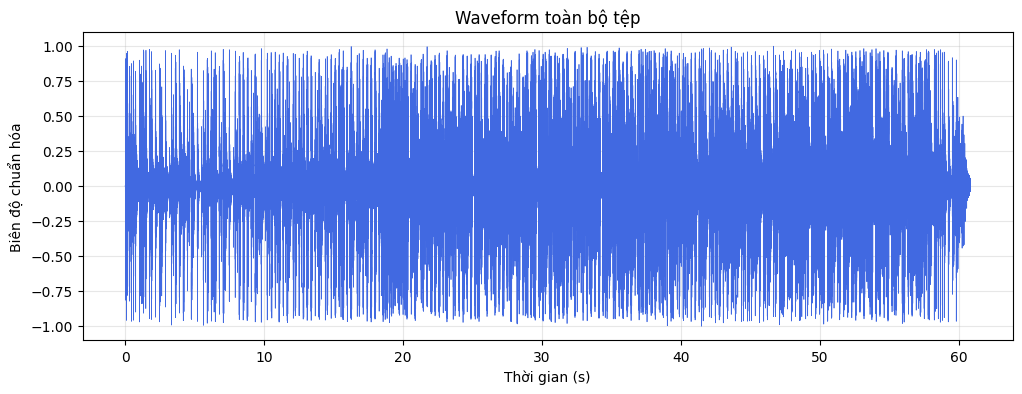

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pydub import AudioSegment

# 1. Đọc file âm thanh từ thư mục audio/
file_path = 'audio/music_input.mp3' # Thay tên tệp của bạn vào đây
audio = AudioSegment.from_file(file_path)

# 2. Kiểm tra siêu dữ liệu (Metadata)
print("--- METADATA ---")
print(f"Tần số lấy mẫu (Fs): {audio.frame_rate} Hz")
print(f"Số kênh gốc: {audio.channels}")
print(f"Độ rộng mẫu: {audio.sample_width * 8} bit/mẫu")
print(f"Thời lượng tệp gốc: {len(audio)/1000.0} giây")

# 3. Chuyển về dạng mono (1 kênh) và chuẩn hóa biên độ
mono = audio.set_channels(1)
Fs = mono.frame_rate

# Lấy mảng dữ liệu và chuẩn hóa về miền [-1, 1] để xử lý số
x = np.array(mono.get_array_of_samples(), dtype=np.float64)
x = x / (2**(8*mono.sample_width - 1))

# 4. Tính toán các đại lượng miền thời gian
print("\n--- PHÂN TÍCH MIỀN THỜI GIAN ---")
print('Thời lượng mảng x:', len(x)/Fs, 'giây')
print('Peak =', np.max(np.abs(x)))
print('RMS  =', np.sqrt(np.mean(x**2)))

# 5. Vẽ waveform toàn bộ tệp
thoi_gian = np.arange(len(x)) / Fs

plt.figure(figsize=(12, 4))
plt.plot(thoi_gian, x, color='royalblue', linewidth=0.5)
plt.title('Waveform toàn bộ tệp')
plt.xlabel('Thời gian (s)')
plt.ylabel('Biên độ chuẩn hóa')
plt.grid(True, alpha=0.3)

# Lưu hình ảnh vào thư mục figures theo cấu trúc yêu cầu
plt.savefig('figures/waveform.png', dpi=300, bbox_inches='tight')
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
C:\Users\nguye\AppData\Local\Temp\ipykernel_18620\4156837874.py:38: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f'Phổ FFT (NFFT = {NFFT_nho}, $\Delta f$ = {delta_f_nho:.2f} Hz)')
C:\Users\nguye\AppData\Local\Temp\ipykernel_18620\4156837874.py:46: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f'Phổ FFT (NFFT = {NFFT_lon}, $\Delta f$ = {delta_f_lon:.2f} Hz)')


Khoảng cách bin tần số (Delta f) khi NFFT=2048: 23.44 Hz
Khoảng cách bin tần số (Delta f) khi NFFT=65536: 0.73 Hz


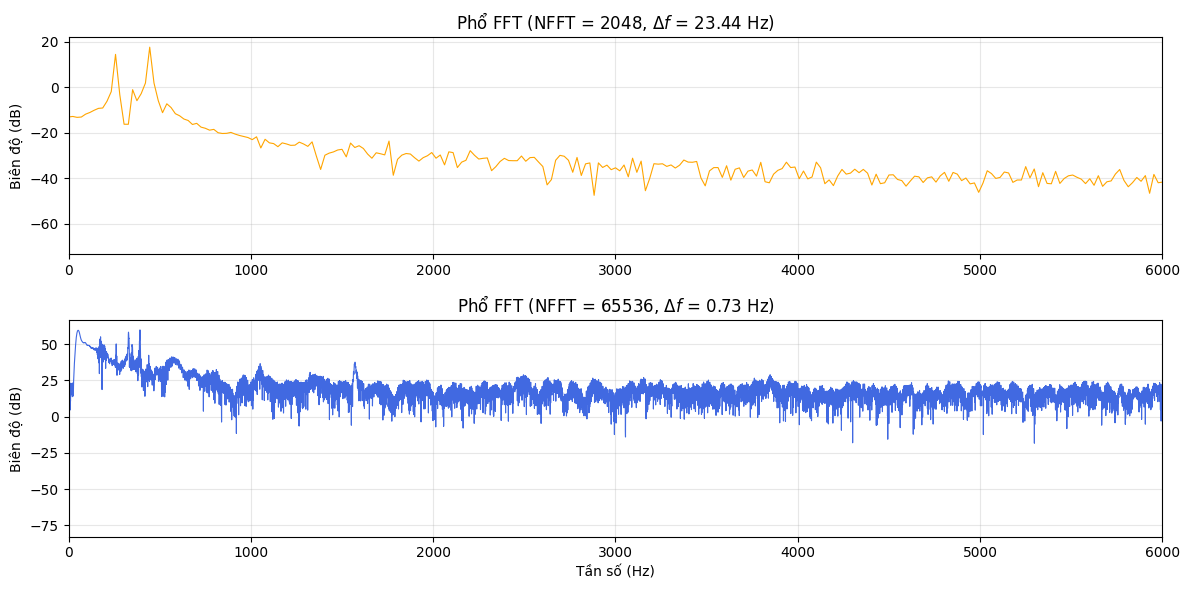

In [2]:
# BƯỚC C: PHÂN TÍCH MIỀN TẦN SỐ (FFT)

# 1. Trích xuất một đoạn âm thanh ổn định dài 1 giây (từ giây 10 đến giây 11)
start_time = 10 
end_time = 11
seg = x[int(start_time * Fs):int(end_time * Fs)]

# 2. Nhân với cửa sổ Hamming để giảm hiện tượng rò rỉ phổ (spectral leakage)
w = np.hamming(len(seg))

# 3. Tính FFT với 2 giá trị NFFT khác nhau (nhỏ và lớn) để so sánh
NFFT_nho = 2048
NFFT_lon = 65536

# Tính FFT cho NFFT nhỏ
X_nho = np.fft.rfft(seg * w, n=NFFT_nho)
f_nho = np.fft.rfftfreq(NFFT_nho, 1/Fs)
mag_db_nho = 20 * np.log10(np.maximum(np.abs(X_nho), 1e-12))

# Tính FFT cho NFFT lớn
X_lon = np.fft.rfft(seg * w, n=NFFT_lon)
f_lon = np.fft.rfftfreq(NFFT_lon, 1/Fs)
mag_db_lon = 20 * np.log10(np.maximum(np.abs(X_lon), 1e-12))

# 4. Tính toán khoảng cách bin tần số (Delta f)
delta_f_nho = Fs / NFFT_nho
delta_f_lon = Fs / NFFT_lon

print(f"Khoảng cách bin tần số (Delta f) khi NFFT={NFFT_nho}: {delta_f_nho:.2f} Hz")
print(f"Khoảng cách bin tần số (Delta f) khi NFFT={NFFT_lon}: {delta_f_lon:.2f} Hz")

# 5. Vẽ biểu đồ so sánh phổ FFT
plt.figure(figsize=(12, 6))

# Đồ thị trên: NFFT nhỏ
plt.subplot(2, 1, 1)
plt.plot(f_nho, mag_db_nho, color='orange', linewidth=0.8)
plt.title(f'Phổ FFT (NFFT = {NFFT_nho}, $\Delta f$ = {delta_f_nho:.2f} Hz)')
plt.ylabel('Biên độ (dB)')
plt.xlim(0, 6000) # Chỉ phóng to dải tần đến 6000 Hz để dễ nhìn
plt.grid(True, alpha=0.3)

# Đồ thị dưới: NFFT lớn
plt.subplot(2, 1, 2)
plt.plot(f_lon, mag_db_lon, color='royalblue', linewidth=0.8)
plt.title(f'Phổ FFT (NFFT = {NFFT_lon}, $\Delta f$ = {delta_f_lon:.2f} Hz)')
plt.xlabel('Tần số (Hz)')
plt.ylabel('Biên độ (dB)')
plt.xlim(0, 6000)
plt.grid(True, alpha=0.3)

plt.tight_layout()
# Lưu hình ảnh vào thư mục figures theo cấu trúc yêu cầu
plt.savefig('figures/fft.png', dpi=300, bbox_inches='tight')
plt.show()

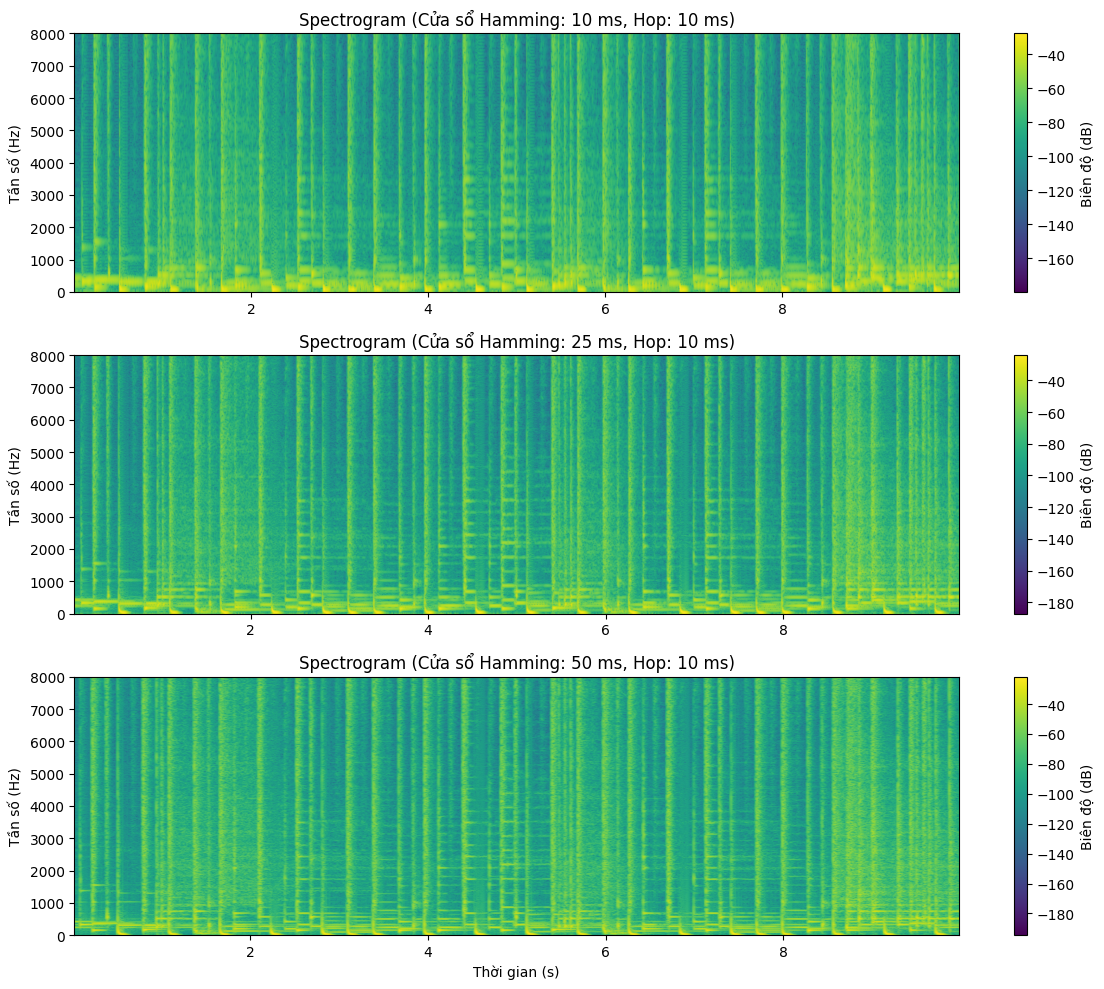

In [4]:
# BƯỚC D & E: STFT VÀ SPECTROGRAM

from scipy import signal
import matplotlib.pyplot as plt
import numpy as np

# 1. Chọn một đoạn âm thanh dài 10 giây (từ giây 10 đến 20)
start_s = 10
end_s = 20
seg_spec = x[int(start_s * Fs):int(end_s * Fs)]

# 2. Thiết lập 3 mức độ dài khung (Frame length): 10ms, 25ms, 50ms
frame_lengths_ms = [10, 25, 50]
hop_ms = 10 

plt.figure(figsize=(12, 10))

# 3. Chạy vòng lặp để vẽ 3 Spectrogram tương ứng
for i, fl_ms in enumerate(frame_lengths_ms):
    L = int((fl_ms / 1000) * Fs)      
    H = int((hop_ms / 1000) * Fs)     
    
    # Tính toán STFT (Đã sửa nfft lên 4096)
    f_spec, t_spec, S = signal.spectrogram(
        seg_spec, fs=Fs, window='hamming',
        nperseg=L, noverlap=L-H, nfft=4096, mode='magnitude'
    )
    
    S_dB = 20 * np.log10(np.maximum(S, 1e-12))
    
    plt.subplot(3, 1, i+1)
    plt.pcolormesh(t_spec, f_spec, S_dB, shading='gouraud', cmap='viridis')
    plt.title(f'Spectrogram (Cửa sổ Hamming: {fl_ms} ms, Hop: {hop_ms} ms)')
    plt.ylabel('Tần số (Hz)')
    plt.ylim(0, 8000) 
    plt.colorbar(label='Biên độ (dB)')
    
    if i == 2:
        plt.xlabel('Thời gian (s)')

plt.tight_layout()
plt.savefig('figures/spectrogram.png', dpi=300, bbox_inches='tight')
plt.show()

Đã xuất thành công tệp âm thanh đã lọc tại: audio/filtered_lpf_2k.wav


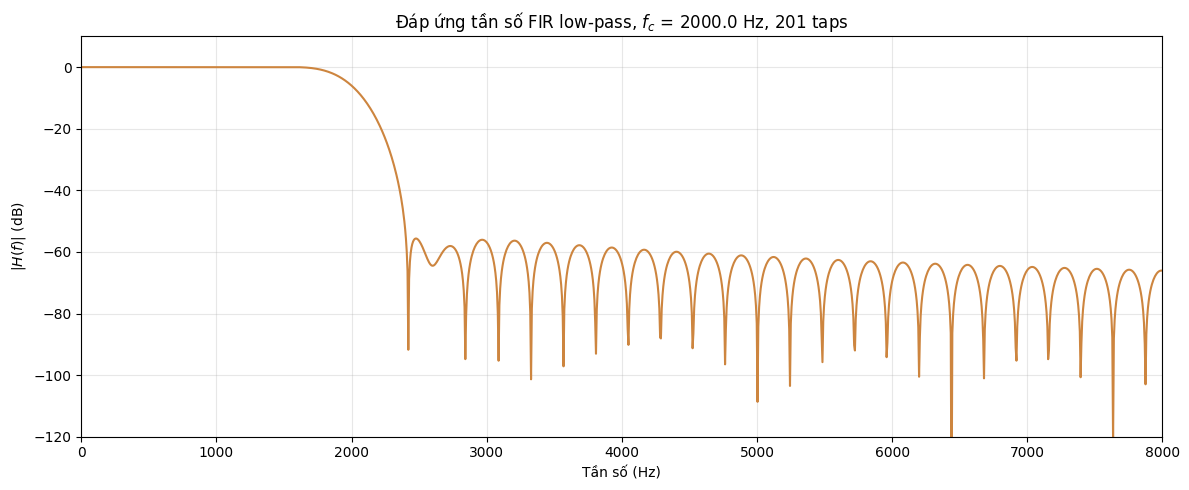

In [6]:
# BƯỚC F: THIẾT KẾ VÀ ÁP DỤNG BỘ LỌC SỐ (FIR LOW-PASS FILTER)

from scipy import signal
import soundfile as sf  # Thư viện để xuất file âm thanh

# 1. Thiết kế bộ lọc FIR low-pass với tần số cắt cắt fc = 2000 Hz, 201 taps
cutoff_freq = 2000.0  # Hz
num_taps = 201
b = signal.firwin(numtaps=num_taps, cutoff=cutoff_freq, fs=Fs, window='hamming')

# 2. Áp dụng bộ lọc lên tín hiệu âm thanh chuẩn hóa x
y = signal.lfilter(b, [1.0], x)

# 3. Tính toán đáp ứng tần số H(f) của bộ lọc
w_resp, H = signal.freqz(b, worN=4096, fs=Fs)
H_dB = 20 * np.log10(np.maximum(np.abs(H), 1e-12))

# 4. Xuất tệp âm thanh sau khi lọc vào thư mục audio/ theo đúng yêu cầu
output_audio_path = 'audio/filtered_lpf_2k.wav'
# Chuyển đổi ngược mảng x về định dạng 16-bit PCM để lưu file wav chuẩn
y_int16 = np.int16(y * 32767)
sf.write(output_audio_path, y_int16, Fs)
print(f"Đã xuất thành công tệp âm thanh đã lọc tại: {output_audio_path}")

# 5. Vẽ biểu đồ đáp ứng tần số H(f) và lưu vào thư mục figures/
plt.figure(figsize=(12, 5))
plt.plot(w_resp, H_dB, color='peru', linewidth=1.5)
plt.title(f'Đáp ứng tần số FIR low-pass, $f_c$ = {cutoff_freq} Hz, {num_taps} taps')
plt.xlabel('Tần số (Hz)')
plt.ylabel('$|H(f)|$ (dB)')
plt.xlim(0, 8000)  # Phóng to dải tần từ 0 đến 8000 Hz để quan sát rõ vùng qua và vùng chắn
plt.ylim(-120, 10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/filter_response.png', dpi=300, bbox_inches='tight')
plt.show()